# Question 1 : Simple Forecast Using Moving Average
Predict the next value using the last 12-month average.
 
Dataset : https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv


In [48]:
import pandas as pd

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates = True, index_col = 'Month')
df = df.asfreq('MS')
df



,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


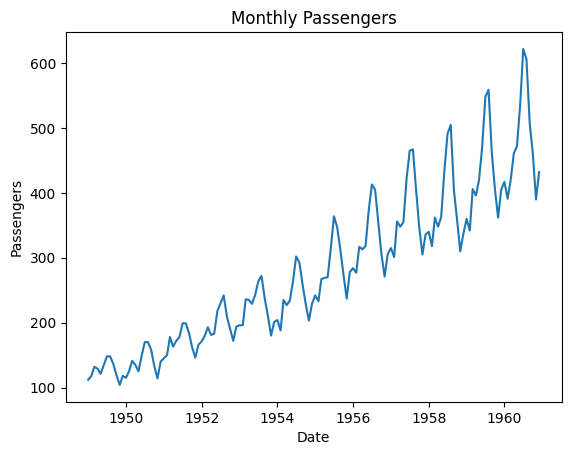

In [ ]:
import matplotlib.pyplot as plt
plt.plot(df.index, df['Passengers'])
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.title('Monthly Passengers')
plt.show()


In [49]:
from statsmodels.tsa.stattools import adfuller

adf_p = adfuller(df['Passengers'], autolag='AIC')[1]
print("ADF p-value:", adf_p, "-", "Stationary" if adf_p < 0.05 else "Non-stationary")


ADF p-value: 0.991880243437641 - Non-stationary


In [55]:
stat_df = df.diff().dropna()
invert_stat_df = stat_df.cumsum() + df.iloc[0,0]
invert_stat_df


,Passengers
Month,
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0
1949-06-01,135.0
...,...
1960-08-01,606.0
1960-09-01,508.0
1960-10-01,461.0


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# Stationarizing the data
# Using last 12 months for prediction
stat_df = df.diff().dropna()
stat_df_12 = stat_df.iloc[-12:]

model = ARIMA(stat_df_12['Passengers'], order=(0,0,1))
model_fit = model.fit() 
forecast = model_fit.forecast(steps=1)
forecast_date = forecast.index[0].date()

# Inverting the differencing to get actual forecasted value
last_val = df.iloc[-1]['Passengers']
last_val_date = df.iloc[-1].name.date()
predicted_val = forecast.iloc[0] + last_val

print(f'No of Passengers as on {last_val_date} : {last_val}')
print(f'Predicted for next month {forecast_date}: { predicted_val.round(2)}')


No of Passengers as on 1960-12-01 : 432
Predicted for next month 1961-01-01: 470.87


# Question 2 : Autocorrelation and Partial Autocorrelation
Plot ACF and PACF to determine seasonality.


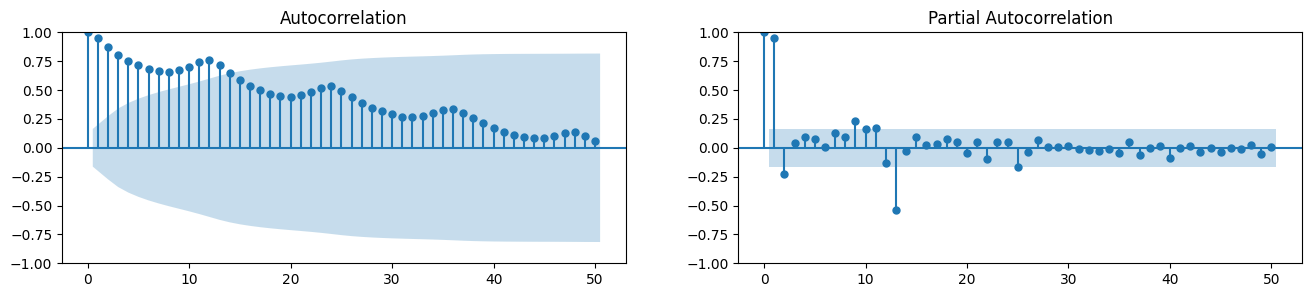

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(df.Passengers.tolist(), lags=50, ax=axes[0])
plot_pacf(df.Passengers.tolist(), lags=50, ax=axes[1])
plt.show()


# Question 3 : Fit ARIMA Model and Forecast
 Fit an ARIMA model to the series and forecast the next 12 months.


Predicted Value:
 1961-01-01    497.128513
1961-02-01    490.300546
1961-03-01    506.790875
1961-04-01    508.000917
1961-05-01    503.479178
1961-06-01    527.108456
1961-07-01    588.487872
1961-08-01    570.616880
1961-09-01    530.987637
1961-10-01    490.801417
1961-11-01    487.206402
1961-12-01    523.516257
Freq: MS, Name: predicted_mean, dtype: float64


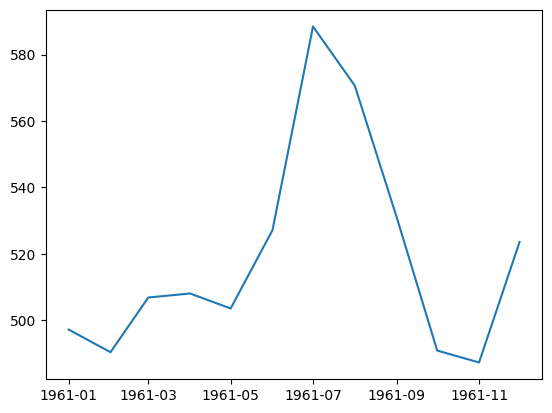

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# Based on ACF and PACF plots, p=2 and q=11 
model = ARIMA(df['Passengers'], order=(2,1,11))
model_fit = model.fit() 
# Forecasting for next 12 months
forecast = model_fit.forecast(steps=12)

print('Predicted Value:\n', forecast)
plt.plot(forecast)
plt.show()


# Question 4 : Load and Visualize the Dataset
Load the dataset and plot the time series.

Dataset : https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv


In [43]:
import pandas as pd

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
df = pd.read_csv(url, parse_dates = True, index_col = 'Date')
df


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8
...,...
1990-12-27,14.0
1990-12-28,13.6
1990-12-29,13.5


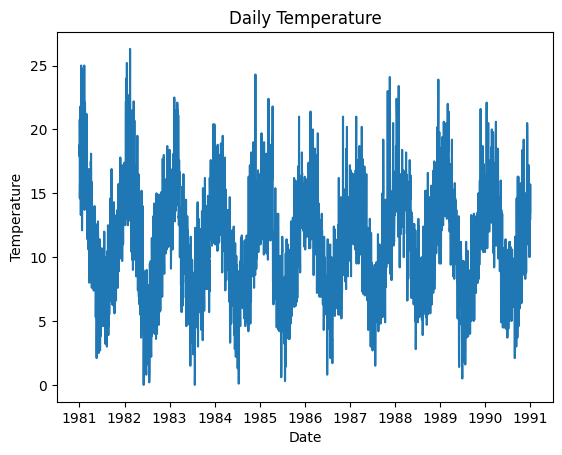

In [ ]:
import matplotlib.pyplot as plt
plt.plot(df.index, df['Temp'])
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Daily Temperature')
plt.show()


# Question 5 : Check for Seasonality with Monthly Mean
Calculate the average temperature for each month.


In [44]:
df_monthly = df['Temp'].resample('ME').mean().to_frame()
df_monthly


,Temp
Date,
1981-01-31,17.712903
1981-02-28,17.678571
1981-03-31,13.500000
1981-04-30,12.356667
1981-05-31,9.490323
...,...
1990-08-31,7.825806
1990-09-30,9.166667
1990-10-31,11.345161


ADF p-value: 0.3357 - Non-stationary


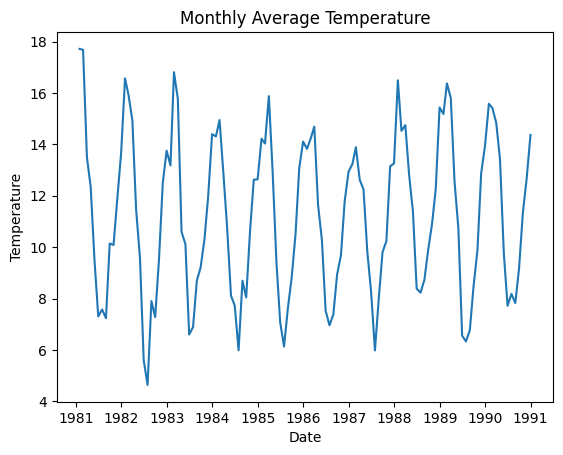

In [46]:
from statsmodels.tsa.stattools import adfuller

adf_p = adfuller(df_monthly['Temp'], autolag='AIC')[1]
print("ADF p-value:", adf_p.round(4), "-", "Stationary" if adf_p < 0.05 else "Non-stationary")

plt.style.use('default')
plt.plot(df_monthly.index, df_monthly['Temp'])
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Monthly Average Temperature')
plt.show()
